<!-- @format -->

# 导入必须库


In [1]:
# ===== 1. 准备工作：导入库、加载并准备数据 ===== 
# 代码运行要按顺序，后面cell的代码受前面影响，当前cell运行出错，请检查cell依赖的cell是否已正确运行
# 代码如果出现bug，清楚所有输出，重启环境再运行
# =============================================================================
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import os  
import warnings 
import re 
from statsmodels.nonparametric.smoothers_lowess import lowess 
import shap
from sklearn.model_selection import train_test_split, GridSearchCV 
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error 
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import gaussian_kde
import warnings
warnings.filterwarnings("ignore")


<!-- @format -->

# 1、数据预处理


<!-- @format -->

## 1.1 配置基本路径


In [2]:
# ===== 用户配置 (请在这里修改文件路径和列名) =====
# =============================================================================
excel_file_path = r'E:\\Python\\project\\xgboost\\O2O指标.xlsx' # 定义Excel数据文件的完整路径
target_column_name = 'Y1' # 定义您数据中作为目标变量（Y值）的列的名称
sheet_name = None # 如果Excel文件有多个工作表，请在这里指定要读取的表名；如果只有一个或读取第一个，则保持为None
output_main_folder = r'E:\\Python\\project\\xgboost\\dependence_pictures' 
interactions_folder = r'E:\\Python\\project\\xgboost\\interactions_pictures'
# =============================================================================


<!-- @format -->

## 1.2 读取加载数据


In [3]:

# plt.rcParams['font.serif'] = ['Times New Roman'] # 设置matplotlib绘图时使用的衬线字体为'Times New Roman'
plt.rcParams['font.sans-serif'] = ['SimHei'] # 设置matplotlib绘图时使用的无衬线字体为'SimHei'（黑体），以正确显示中文
plt.rcParams['axes.unicode_minus'] = False # 设置matplotlib正常显示负号

def sanitize_filename(name): # 定义一个函数，用于清理文件名中的非法字符
    return re.sub(r'[\\/*?:"<>|]', '_', name) # 使用正则表达式将Windows文件名中的非法字符替换为下划线
# 打印任务开始的提示信息
print("--- 开始读取数据 ---")
print(f"正在从 '{excel_file_path}' 加载数据...")
# 检查用户是否指定了工作表名称
if sheet_name:
    # 如果指定了，则读取特定的工作表
    df = pd.read_excel(excel_file_path, sheet_name=sheet_name)
else: 
    # 如果没有指定工作表名称,默认读取Excel文件的第一个工作表
    df = pd.read_excel(excel_file_path)
# 如果数据成功加载，打印成功信息
print("数据加载成功！")

# 检查目标列是否存在于DataFrame的列名中
if target_column_name not in df.columns:
    # 如果不存在，打印错误信息
    print(f"错误：目标列 '{target_column_name}' 不存在于数据中！")
    # 并列出所有可用的列名，方便用户检查
    print(f"可用的列为: {df.columns.tolist()}") 


--- 开始读取数据 ---
正在从 'E:\\Python\\project\\xgboost\\O2O指标.xlsx' 加载数据...
数据加载成功！


<!-- @format -->

## 1.3 识别自变量和因变量


In [4]:
# 将目标列的数据赋值给变量y
y = df[target_column_name]
# 从DataFrame中删除目标列，剩下的作为特征集赋值给X
#X = df.drop(columns=[target_column_name])
cols = ['X1','X2','X3','X4','X6','X7','X8','X19','X10','X14','X17','X18','X22']
X = df[cols]
# 获取所有特征的名称，并存为一个列表
feature_names = X.columns.tolist()
# 打印目标列设置成功的提示
print(f"因变量--->'{target_column_name}'列。")
print('*'*50)
# 打印找到的特征数量和名称列表
print(f"共 {len(feature_names)} 个特征用于模型训练: \n{feature_names}")


因变量--->'Y1'列。
**************************************************
共 13 个特征用于模型训练: 
['X1', 'X2', 'X3', 'X4', 'X6', 'X7', 'X8', 'X19', 'X10', 'X14', 'X17', 'X18', 'X22']


<!-- @format -->

## 1.4 数据类型转化


In [5]:
# 打印数据预处理开始的提示
print("正在检查并处理非数值特征...")
# 遍历所有特征列
for col in X.columns: 
    # 检查该列的数据类型是否为'object'（通常是字符串）
    if X[col].dtype == 'object':
        # 如果是，打印提示信息
        print(f"特征 '{col}' 是非数值类型，将尝试进行处理。")
        # 尝试将该列转换为数值类型，'coerce'会将无法转换的值变为NaN
        X_converted = pd.to_numeric(X[col], errors='coerce')
         # 如果转换后所有值都变成了NaN，说明该列是纯文本
        if X_converted.isnull().all():
            # 打印将要进行因子化编码的提示
            print(f"特征 '{col}' 是纯文本分类特征，进行编码~") 
            # 使用pandas的factorize方法将文本转换为数字编码
            X[col], _ = pd.factorize(X[col])
        else: # 如果部分值可以被转换
            # 将转换后的列（包含NaN）赋回原处
            X[col] = X_converted
            # 检查是否存在因转换失败而产生的NaN值
            if X[col].isnull().sum() > 0:
                # 计算该列的中位数
                median_val = X[col].median() 
                # 打印将要用中位数填充的提示
                print(f"特征 '{col}' 中存在部分无法转换的值，将使用中位数 ({median_val:.2f}) 进行填充。")
                X[col].fillna(median_val, inplace=True) # 使用中位数填充NaN值
print("数据预处理完成~~") # 打印数据预处理完成的提示


正在检查并处理非数值特征...
数据预处理完成~~


<!-- @format -->

## 1.5 划分训练集和测试集


In [6]:
# ===== 2. 数据集划分、超参数搜索与模型训练 (模型为XGBoost) =====
# =============================================================================
print("\n正在划分训练集和验证集...") # 打印数据集划分开始的提示
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # 使用train_test_split划分数据，20%作为测试集
print(f"训练集: {X_train.shape[0]}个样本")
print(f"验证集: {X_test.shape[0]}个样本") # 打印划分结果的样本数量



正在划分训练集和验证集...
训练集: 2856个样本
验证集: 714个样本


<!-- @format -->

## 1.6 网格搜索训练最佳 XGBoost 模型


In [7]:
 # 打印超参数搜索开始的提示
import xgboost as xgb 
from sklearn.model_selection import KFold
print("\n正在为XGBoost模型进行超参数搜索...")
# 定义一个字典，包含了希望搜索的超参数及其候选值
param_grid = {
    'n_estimators': [300,400,500], # 树的数量
    'max_depth': [2,3,5,10], # 树的最大深度
    'learning_rate': [0.01] # 学习率
}
 # 初始化一个XGBoost回归模型，设置随机种子和评估指标
xgb_model = xgb.XGBRegressor(random_state=0, eval_metric='rmse')
# 定义交叉验证方式，固定随机种子
cv = KFold(n_splits=3, shuffle=True, random_state=0)
# 配置网格搜索，使用3折交叉验证，并行计算，并打印过程信息
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, scoring='neg_mean_squared_error', cv=cv,n_jobs=-1, verbose=1) 
# 在训练集上执行网格搜索
grid_search.fit(X_train, y_train) 
# 获取网格搜索找到的最佳模型
model = grid_search.best_estimator_ 
# 打印找到的最佳超参数组合
print(f"找到的最佳参数为: {grid_search.best_params_}")
# 使用模型对训练集进行预测
y_train_pred = model.predict(X_train)
# 使用模型对测试集进行预测
y_test_pred = model.predict(X_test)
# 计算训练集的指标
r2_train = r2_score(y_train, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
mae_train = mean_absolute_error(y_train, y_train_pred)
# 计算验证集的指标
r2_test = r2_score(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae_test = mean_absolute_error(y_test, y_test_pred)
print("*"*100)
print(f"训练集评估指标: R2={r2_train:.4f}, RMSE={rmse_train:.4f}, MAE={mae_train:.4f}")
print("*"*100)
print(f"验证集评估指标: R2={r2_test:.4f}, RMSE={rmse_test:.4f}, MAE={mae_test:.4f}")
# ====================================



正在为XGBoost模型进行超参数搜索...
Fitting 3 folds for each of 12 candidates, totalling 36 fits
找到的最佳参数为: {'learning_rate': 0.01, 'max_depth': 2, 'n_estimators': 500}
****************************************************************************************************
训练集评估指标: R2=0.5341, RMSE=2.1107, MAE=1.0391
****************************************************************************************************
验证集评估指标: R2=0.4169, RMSE=1.6107, MAE=0.9501


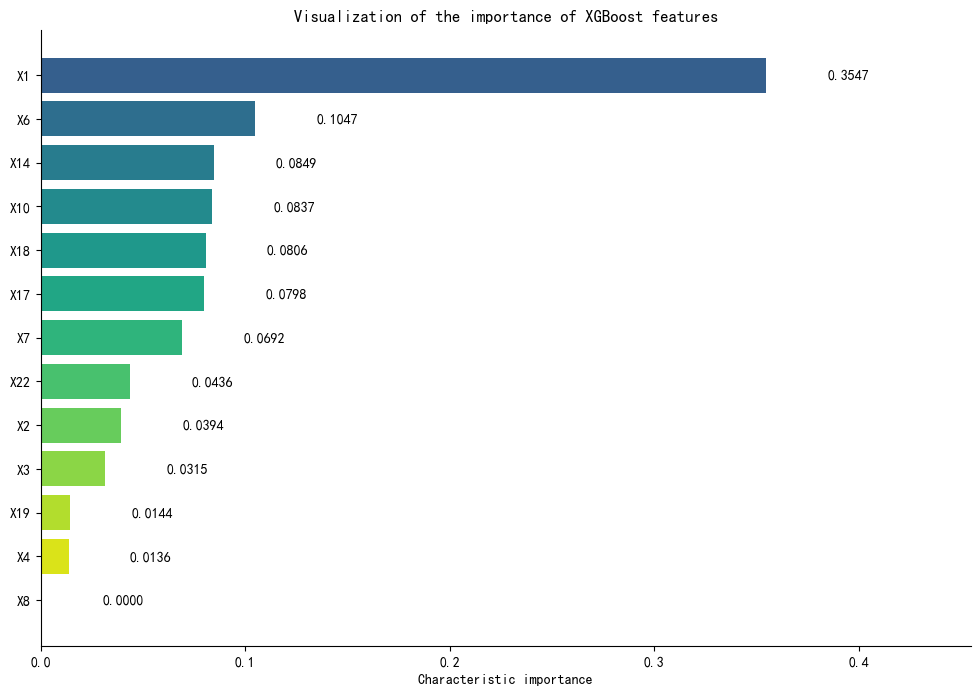

In [8]:

feature_importances = model.feature_importances_
# 将特征重要性与特征名称对应，并按重要性降序排列
importance_df = pd.DataFrame({'特征': X.columns, '重要性': feature_importances})
importance_df = importance_df.sort_values(by='重要性', ascending=False)
# 绘制特征重要性柱状图
plt.figure(figsize=(12, 8))
colors = plt.cm.viridis(np.linspace(0.3, 1, len(importance_df)))
plt.barh(importance_df['特征'], importance_df['重要性'], color=colors)
plt.xlabel('Characteristic importance')
plt.title('Visualization of the importance of XGBoost features')
plt.gca().invert_yaxis()  # 反转y轴，使最重要的特征在顶部
# 设置x轴的最大值为特征最大值加0.1
plt.xlim(0, importance_df['重要性'].max() + 0.1)
# 在每个条形上显示数值
for index, value in enumerate(importance_df['重要性']):
    plt.text(value+0.03, index, f'{value:.4f}', va='center')
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

In [9]:

# 将特征重要性与特征名称对应，并按重要性降序排列
importance_df = pd.DataFrame({'特征': X.columns, '重要性': feature_importances})
importance_df = importance_df.sort_values(by='重要性', ascending=False)

# 输出特征重要性排序
importance_df

,特征,重要性
0,X1,0.354658
4,X6,0.104659
9,X14,0.084912
8,X10,0.083701
11,X18,0.080606
10,X17,0.079797
5,X7,0.069167
12,X22,0.043629
1,X2,0.039417
2,X3,0.031465


<!-- @format -->

## 1.7 散点图可视化预测结果


<!-- @format -->

## 1.8 预测效果折线图可视化


<!-- @format -->

# 2、Shap 分析


<!-- @format -->

## 2.1 测试集计算 shap 值


In [10]:
# ===== 3. SHAP分析 (关键修正：所有计算基于X_test) =====
# =============================================================================
print(" 在测试集上计算SHAP值...") # 打印开始在测试集上计算SHAP值的提示
# 使用训练好的最佳模型创建一个SHAP解释器
explainer = shap.Explainer(model)
# 将测试集数据传入解释器，计算每个样本每个特征的SHAP值
shap_values_obj = explainer(X_test)
# 从SHAP解释对象中提取SHAP值矩阵
shap_values = shap_values_obj.values
# 计算每个特征的SHAP绝对值的平均值，作为其重要性度量
mean_shap = np.abs(shap_values).mean(axis=0)
 # 创建一个DataFrame来存储特征名和其重要性
shap_df = pd.DataFrame({
    "feature": feature_names, # 特征名称列
    "mean_shap": mean_shap # 平均绝对SHAP值列
}).sort_values("mean_shap", ascending=False) # 按重要性降序排序
# 获取排序后的特征名称列表
sorted_features = shap_df["feature"].values
# 按照排序后的特征顺序，重新排列测试集的列
X_test_sorted = X_test[sorted_features]
# 获取排序后特征在原始特征列表中的索引
orig_index = [feature_names.index(f) for f in sorted_features]
# 按照新的特征顺序，重新排列SHAP值矩阵的列
shap_values_sorted = shap_values[:, orig_index]
# 打印计算完成的提示
print("主效应SHAP值计算完成。")
X_test_sorted

 在测试集上计算SHAP值...
主效应SHAP值计算完成。


,X1,X6,X17,X10,X18,X3,X22,X14,X4,X19,X2,X7,X8
457,10630.555556,2.777778,2.777778,1.565445,33.333333,0.151611,1376.522301,0.000000,0.873424,1500.000000,0.061171,0.000000,8.764748
1565,4661.111111,0.000000,11.111111,1.440630,8.333333,0.229942,3000.000000,0.000000,0.828778,1500.000000,0.076503,0.000000,6.376955
351,57619.444444,80.555556,94.444444,2.044363,216.666667,0.309621,1320.091334,128.285714,0.871514,488.708315,0.107564,1.821505,10.588396
1665,14552.777778,150.000000,16.666667,1.457667,152.777778,0.331532,1183.327046,166.125000,0.874867,609.789100,0.124429,0.622596,10.011472
1847,16202.777778,16.666667,19.444444,1.876228,188.888889,0.252968,507.183549,64.000000,0.870024,1206.780244,0.092049,1.640776,2.709932
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2167,22041.666667,30.555556,41.666667,1.851071,133.333333,0.318054,598.674311,305.800000,0.819954,1500.000000,0.081864,1.758766,9.921449
2712,3305.555556,0.000000,13.888889,0.000000,2.777778,0.174101,3000.000000,0.000000,0.852267,1500.000000,0.070008,0.000000,5.178666
2004,30080.555556,16.666667,69.444444,1.838824,36.111111,0.452618,1340.704947,0.000000,0.899413,528.868669,0.206130,0.000000,1.113955
1104,200.000000,0.000000,0.000000,0.000000,0.000000,0.268231,1548.641311,0.000000,0.928754,847.347041,0.056510,0.000000,0.000000


<!-- @format -->

## 2.2 绘制 shap 特征重要性蜂窝图+柱状图



正在绘制 SHAP 特征重要性图...


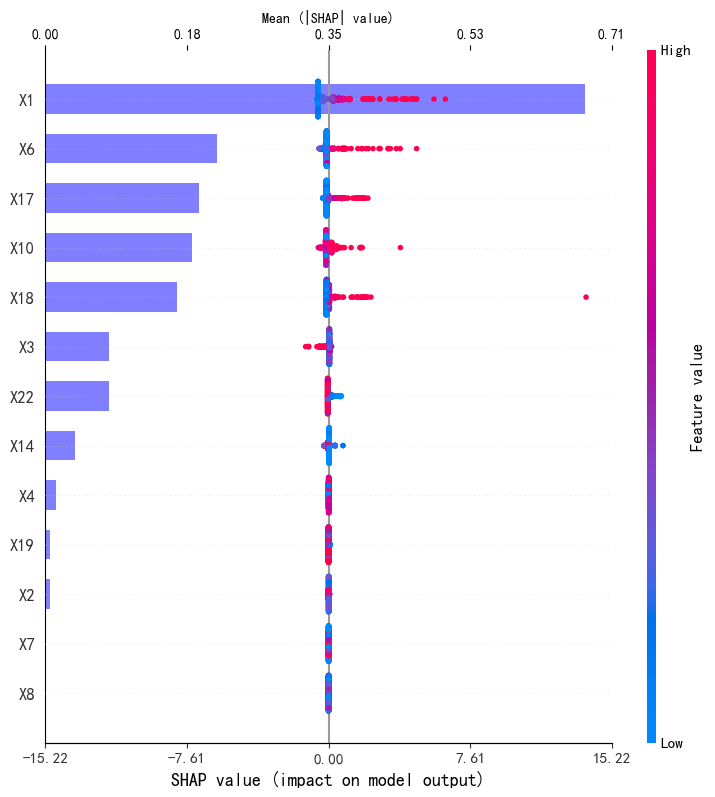

In [11]:
print("\n正在绘制 SHAP 特征重要性图...")

# 创建一个图形窗口，设置大小为12x6英寸
fig = plt.figure(figsize=(12, 9))
# 创建一个轴对象，用于绘制SHAP值的散点图
ax_sw = fig.add_axes([0.32, 0.11, 0.59, 0.77])
# 创建一个双轴，用于绘制条形图
ax_bar = ax_sw.twiny()
# 设置双轴的绘图顺序，确保条形图在散点图的后面
ax_bar.set_zorder(0)
ax_sw.set_zorder(1)
# 设置散点图的背景透明度为0，使其不可见
ax_sw.patch.set_alpha(0)
# 创建y轴的位置数组，用于条形图和散点图的y轴刻度
y_pos = np.arange(len(sorted_features))[::-1]
# 绘制条形图，显示每个特征的平均绝对SHAP值
ax_bar.barh(y=y_pos, width=shap_df["mean_shap"].values, height=0.6, color="blue", alpha=0.5, edgecolor="none", zorder=0)
# 设置条形图的x轴范围，稍微超出最大值
xlim_bar = shap_df["mean_shap"].values.max() * 1.05
ax_bar.set_xlim(0, xlim_bar)
# 设置条形图的x轴刻度位置
xticks_bar = np.linspace(0, xlim_bar, 5)
ax_bar.set_xticks(xticks_bar)
# 设置条形图的x轴刻度标签，格式化为两位小数
ax_bar.set_xticklabels([f"{x:.2f}" for x in xticks_bar])
# 设置条形图的x轴标签
ax_bar.set_xlabel("Mean (|SHAP| value)", fontsize=10)
# 设置条形图的y轴刻度位置
ax_bar.set_yticks(y_pos)
# 计算SHAP值的最大绝对值，用于设置散点图的x轴范围
max_abs_shap = np.abs(shap_values_sorted).max()
# 设置散点图的x轴范围，稍微超出最大绝对值
xlim_sw = max_abs_shap * 1.1
ax_sw.set_xlim(-xlim_sw, xlim_sw)
# 设置散点图的x轴刻度位置
sw_xticks = np.linspace(-xlim_sw, xlim_sw, 5)
ax_sw.set_xticks(sw_xticks)
# 设置散点图的x轴刻度标签，格式化为两位小数
ax_sw.set_xticklabels([f"{x:.2f}" for x in sw_xticks])
# 设置散点图的x轴标签
ax_sw.set_xlabel("SHAP value (impact on model output)", fontsize=10)
# 创建一个SHAP解释对象，用于绘制散点图
expl_main = shap.Explanation(
    values=shap_values_sorted,  # SHAP值
    data=X_test_sorted.values,  # 测试数据
    feature_names=list(sorted_features),  # 特征名称
    base_values=shap_values_obj.base_values[0]  # 基础值
)
# 使用SHAP的beeswarm图绘制散点图
shap.plots.beeswarm(expl_main, max_display=len(sorted_features), ax=ax_sw, show=False, plot_size=None)
# 设置散点图的y轴刻度位置
ax_sw.set_yticks(y_pos)
# 设置散点图的y轴刻度标签，显示特征名称
ax_sw.set_yticklabels(sorted_features, fontsize=12)
# 设置散点图的y轴刻度参数
ax_sw.tick_params(axis='y', length=4)
# 隐藏散点图的上边框线和右边框线
ax_sw.spines['top'].set_visible(False)
ax_sw.spines['right'].set_visible(False)
# 隐藏条形图的上边框线和右边框线
ax_bar.spines['top'].set_visible(False)
ax_bar.spines['right'].set_visible(False)
# 保存图形为PNG文件，确保图形完整
plt.savefig("shap_feature_importance.png", bbox_inches="tight")
# 显示图形
plt.show()

<!-- @format -->

## 2.4 绘制单个样本 shap 力图


<!-- @format -->

## 2.5 绘制 shap 热图


<!-- @format -->

## 2.6 绘制所有样本 shap 力图


<!-- @format -->

## 2.7 绘制 shap 特征依赖图


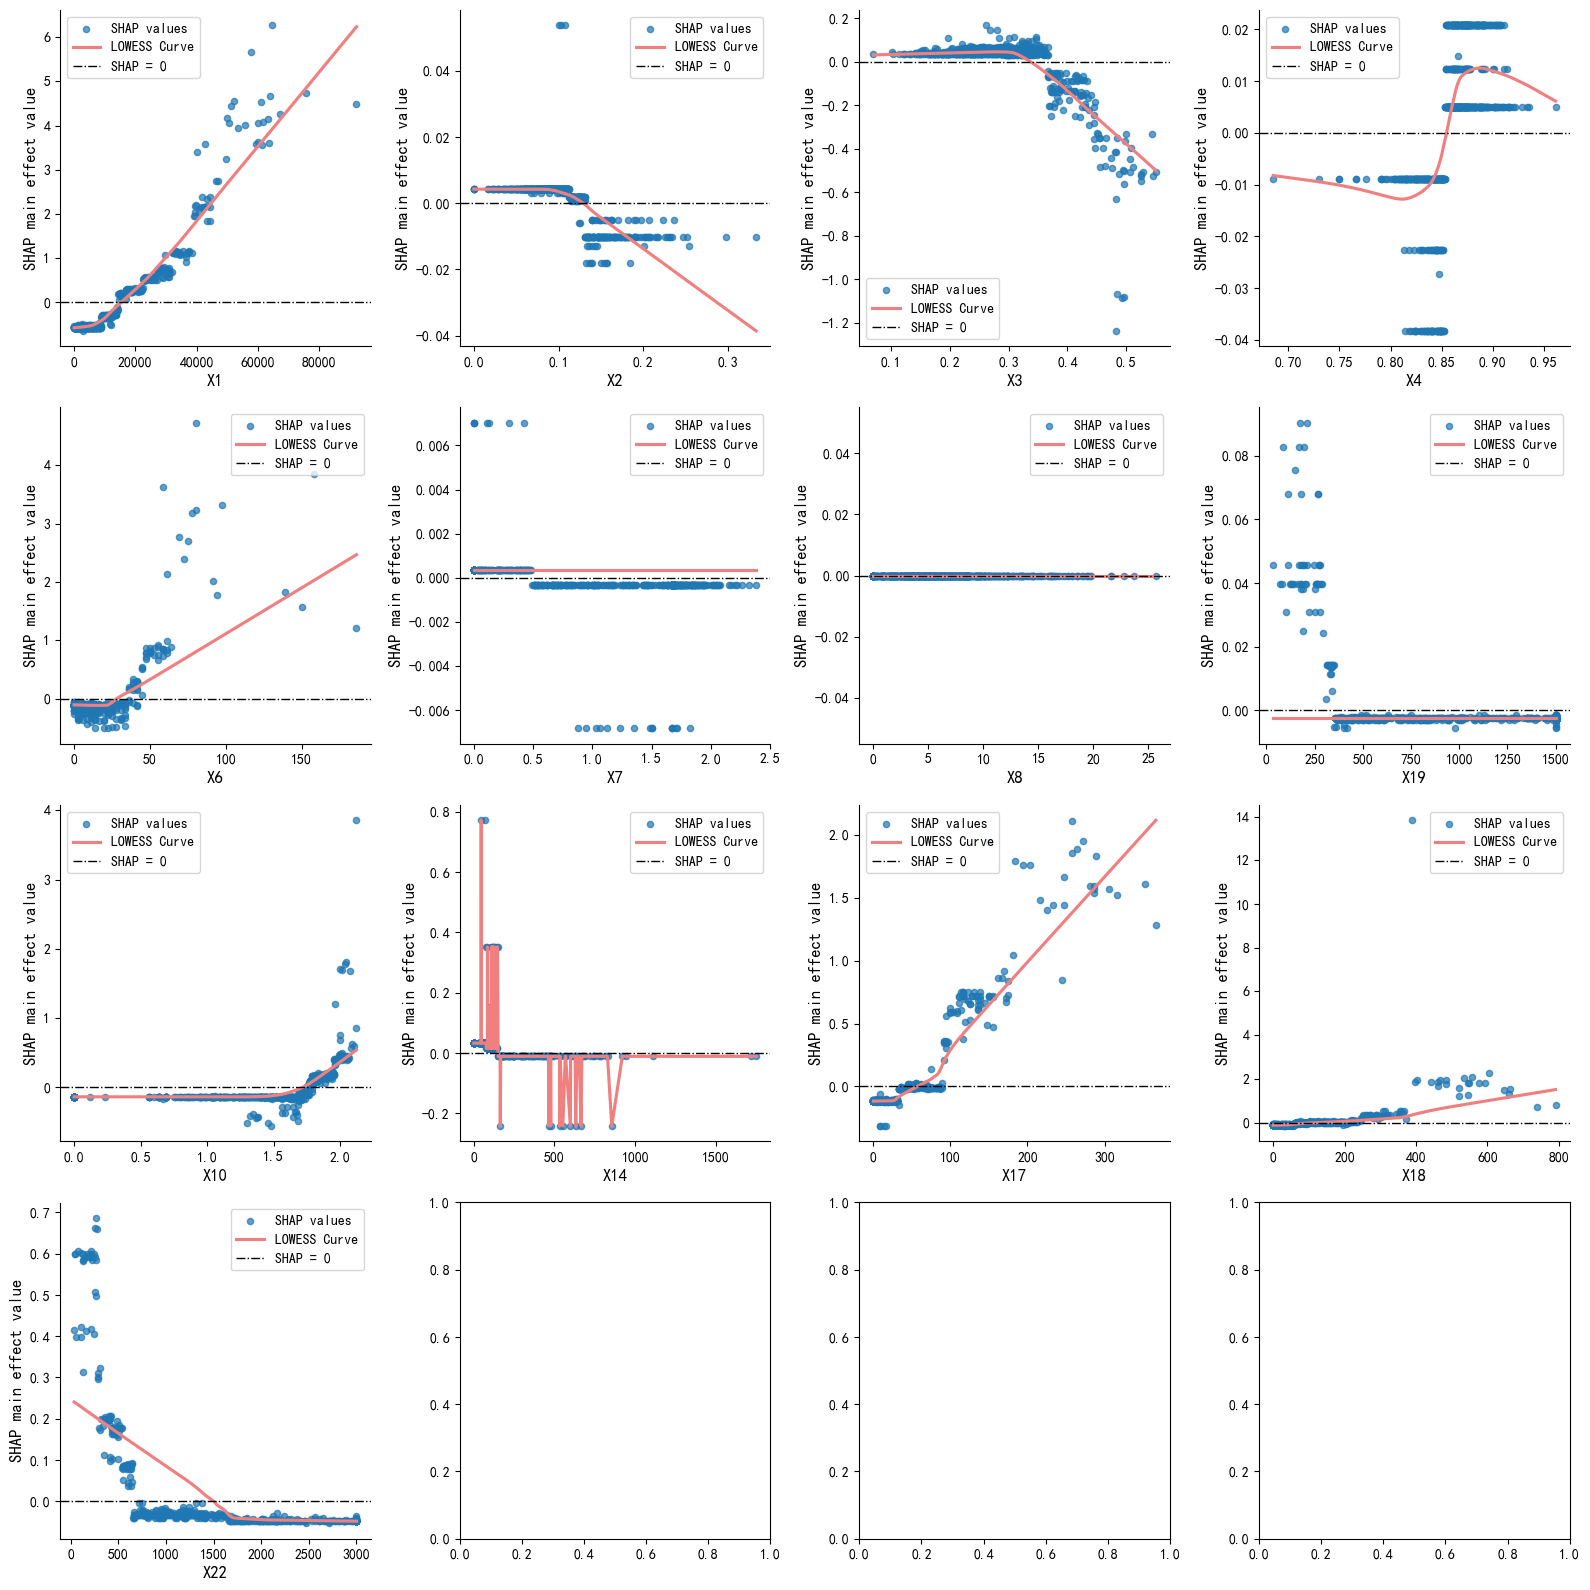

In [12]:
# 假设 shap_values_df 和 X_test 已经定义
shap_values_df = pd.DataFrame(shap_values_obj.values, columns=X_test.columns)

# 获取特征名称
features = X_test.columns
# 创建2×4的子图网格
fig, axs = plt.subplots(4, 4, figsize=(16, 16))  # 调整figsize以适应子图大小
# 遍历前8个特征，绘制每个特征的散点图和LOWESS拟合曲线
for i, feature in enumerate(features):
    row = i // 4  # 计算当前特征所在的行
    col = i % 4   # 计算当前特征所在的列
    ax = axs[row, col]
    # 绘制散点图
    ax.scatter(X_test[feature], shap_values_df[feature], s=20, label='SHAP values', alpha=0.7)
    # 添加LOWESS拟合曲线
    sns.regplot(x=X_test[feature], y=shap_values_df[feature], scatter=False, lowess=True, color='lightcoral', label='LOWESS Curve', ax=ax)
    # 添加y=0的横线
    ax.axhline(y=0, color='black', linestyle='-.', linewidth=1, label='SHAP = 0')
    # 设置标签
    ax.set_xlabel(feature, fontsize=12)
    ax.set_ylabel('SHAP main effect value', fontsize=12)
    
    # 添加图例
    ax.legend()
    
    # 去除上和右的边框线
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
# 调整子图之间的间距
plt.tight_layout()
plt.savefig('shap_dependence_plots.png', dpi=300)
# 显示图形
plt.show()

<!-- @format -->


<!-- @format -->
